<a href="https://colab.research.google.com/github/Aksaiful007/Intrusion_detection_system1_CIC2017/blob/main/final_ids_Friday_CIC_IDS2017.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install catboost
!pip install xgboost
!pip install lightgbm
!pip install imblearn

## Importing important libraries


In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
#importing important libraries..
import warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import gc, os
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import mutual_info_classif

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Display Options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot Style
plt.style.use("ggplot")

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 11})
SEED = 42
np.random.seed(SEED)
print("Environment ready")

Environment ready


In [24]:

import os

folder = "/content/drive/MyDrive/friday_data"

files = sorted([
    os.path.join(folder, f)
    for f in os.listdir(folder)
    if f.endswith(".csv") and f != "friday_sample_30k.csv"
])


df = pd.concat(
    (pd.read_csv(f) for f in files),
    ignore_index=True
)

print(df.shape)

print(df.shape)
print(df.head().T)
print(df.head().T)

(703245, 79)
(703245, 79)
                                        0            1            2  \
 Destination Port                   54865        55054        55055   
 Flow Duration                          3          109           52   
 Total Fwd Packets                      2            1            1   
 Total Backward Packets                 0            1            1   
Total Length of Fwd Packets            12            6            6   
 Total Length of Bwd Packets            0            6            6   
 Fwd Packet Length Max                  6            6            6   
 Fwd Packet Length Min                  6            6            6   
 Fwd Packet Length Mean               6.0          6.0          6.0   
 Fwd Packet Length Std                0.0          0.0          0.0   
Bwd Packet Length Max                   0            6            6   
 Bwd Packet Length Min                  0            6            6   
 Bwd Packet Length Mean               0.0          

# Dataset assesment and primary observation...

In [25]:
# Data observation and exploration..
print(df.shape)
print("---------------------------------")
print(df.info())
print("------------------------------------------------------")
print(df.describe().T)
print("------------------------------------------------------")
print(df.head())

(703245, 79)
---------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 703245 entries, 0 to 703244
Data columns (total 79 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0    Destination Port             703245 non-null  int64  
 1    Flow Duration                703245 non-null  int64  
 2    Total Fwd Packets            703245 non-null  int64  
 3    Total Backward Packets       703245 non-null  int64  
 4   Total Length of Fwd Packets   703245 non-null  int64  
 5    Total Length of Bwd Packets  703245 non-null  int64  
 6    Fwd Packet Length Max        703245 non-null  int64  
 7    Fwd Packet Length Min        703245 non-null  int64  
 8    Fwd Packet Length Mean       703245 non-null  float64
 9    Fwd Packet Length Std        703245 non-null  float64
 10  Bwd Packet Length Max         703245 non-null  int64  
 11   Bwd Packet Length Min        703245 non-null  int64  
 1

In [26]:

print(df.nunique())
print("------------------------------------------------------------")
print(df.columns)
print("--------------------------------------------------------------------------")
print(df.describe(include = "object").T)
print("---------------------------------------------------------------")
print(df.isnull().sum())
print("------------------------------------------------------------------------")
print(f"The number of duplicated values in the dataset is : {df.duplicated().sum()}")

 Destination Port                38213
 Flow Duration                  314197
 Total Fwd Packets                 651
 Total Backward Packets            823
Total Length of Fwd Packets       8702
 Total Length of Bwd Packets     22080
 Fwd Packet Length Max            3509
 Fwd Packet Length Min             221
 Fwd Packet Length Mean          27746
 Fwd Packet Length Std           48790
Bwd Packet Length Max             3758
 Bwd Packet Length Min             431
 Bwd Packet Length Mean          37181
 Bwd Packet Length Std           48772
Flow Bytes/s                    401585
 Flow Packets/s                 336477
 Flow IAT Mean                  332303
 Flow IAT Std                   291716
 Flow IAT Max                   220670
 Flow IAT Min                    41613
Fwd IAT Total                   132197
 Fwd IAT Mean                   188243
 Fwd IAT Std                    175407
 Fwd IAT Max                    131429
 Fwd IAT Min                     30140
Bwd IAT Total            

# Explorary data analysis..

In [27]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("----------------------------------------------------------")
cat_cols = df.select_dtypes(include="object").columns.tolist()
print(num_cols)
print(cat_cols)

# Use the cleaned column name after stripping whitespace from headers
label_col = "Label" if "Label" in df.columns else next((col for col in df.columns if col.strip() == "Label"), None)

if label_col is None:
    raise KeyError("No target column named 'Label' was found. Check the CSV header names.")

print(df[label_col].value_counts())

#normalizing the target column
print(df[label_col].value_counts(normalize=True) * 100)


----------------------------------------------------------
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Fla

# Data cleaning ...}

In [28]:
#De-duplicating the dataset...
df = df.drop_duplicates().reset_index(drop=True)

#droping infinite vlaues from the dataset....
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

df.replace([np.inf, -np.inf], np.nan, inplace=True)

print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

#Droping nan values form the dataset...
print(df.isnull().sum().sum())
df.dropna(inplace=True)
print(df.isnull().sum().sum())

#eleminating white spaces from column names...
print(df.columns.to_list())
df.columns = df.columns.str.strip()
print(df.columns.to_list())


875
0
922
0
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', ' ACK Flag Count',

In [29]:
## binaray encoding the target column...
df["Label"] = df["Label"].apply(
    lambda x: 0 if x == "BENIGN" else 1
)
print(df["Label"].value_counts())

Label
0    394777
1    220656
Name: count, dtype: int64


# Data visualization..

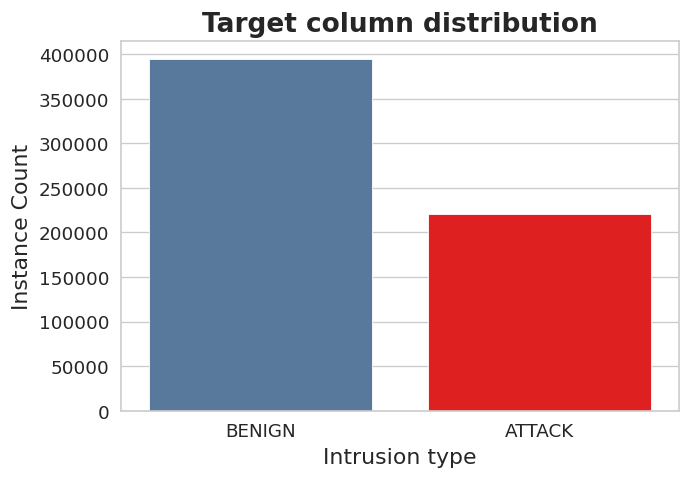

In [30]:
# Visualizing the target column...
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Label",

    palette=["#4C78A8", "#FF0000"],
)

plt.title("Target column distribution", fontweight="bold")
plt.xlabel("Intrusion type")
plt.ylabel("Instance Count")
ax.set_xticklabels(["BENIGN", "ATTACK"])
plt.savefig("Target Column distribution.png", bbox_inches="tight")

plt.show()

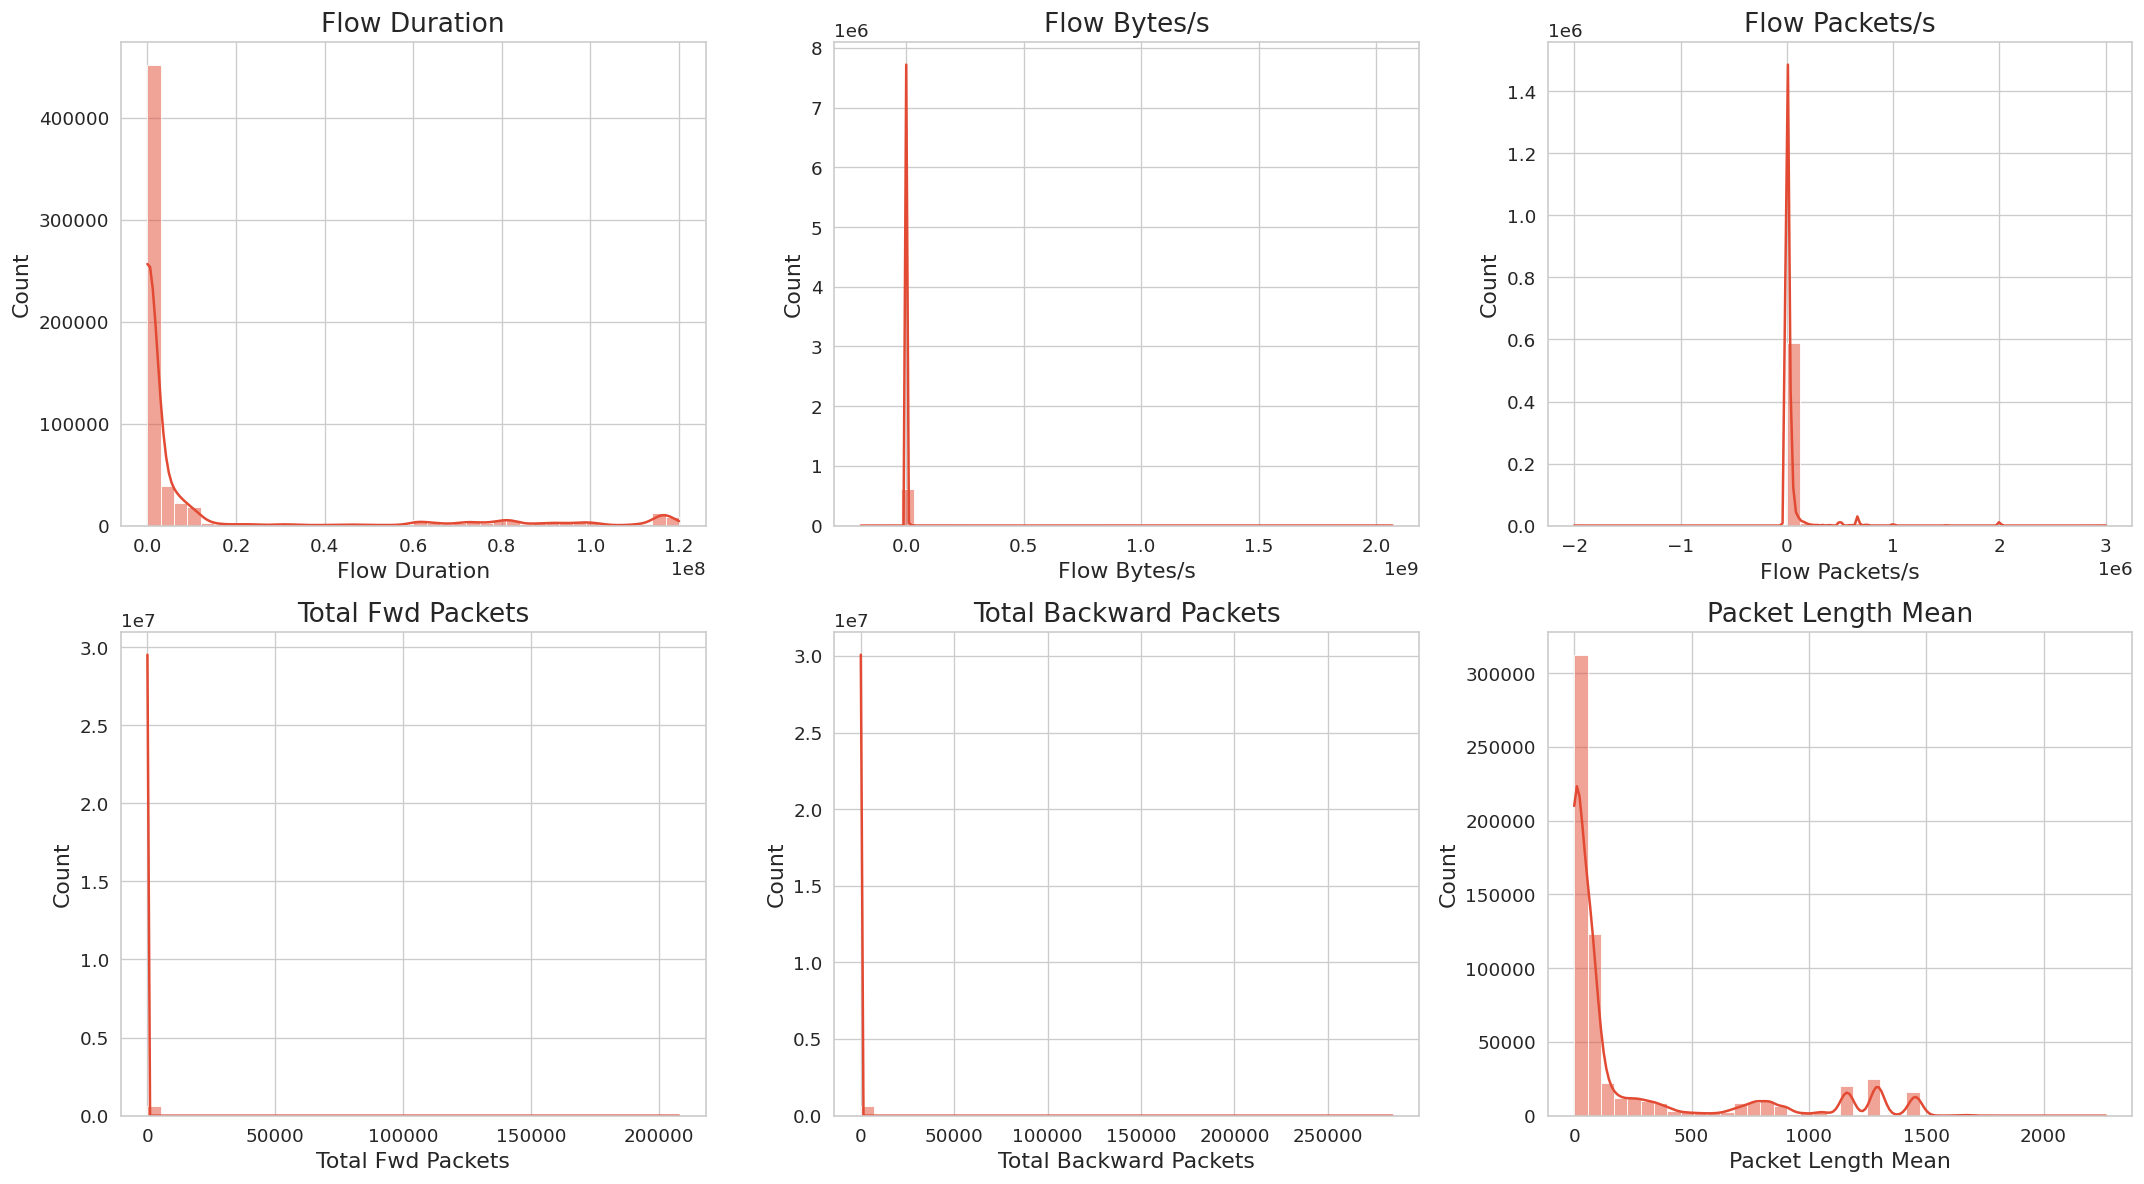

In [31]:
#Distribution of some important feature..
features = [
    "Flow Duration",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Packet Length Mean"
]
fig, axes = plt.subplots(2,3,figsize=(18,10))

axes = axes.flatten()

for ax,col in zip(axes,features):

    sns.histplot(
        df[col],
        bins=40,
        kde=True,
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()

plt.show()

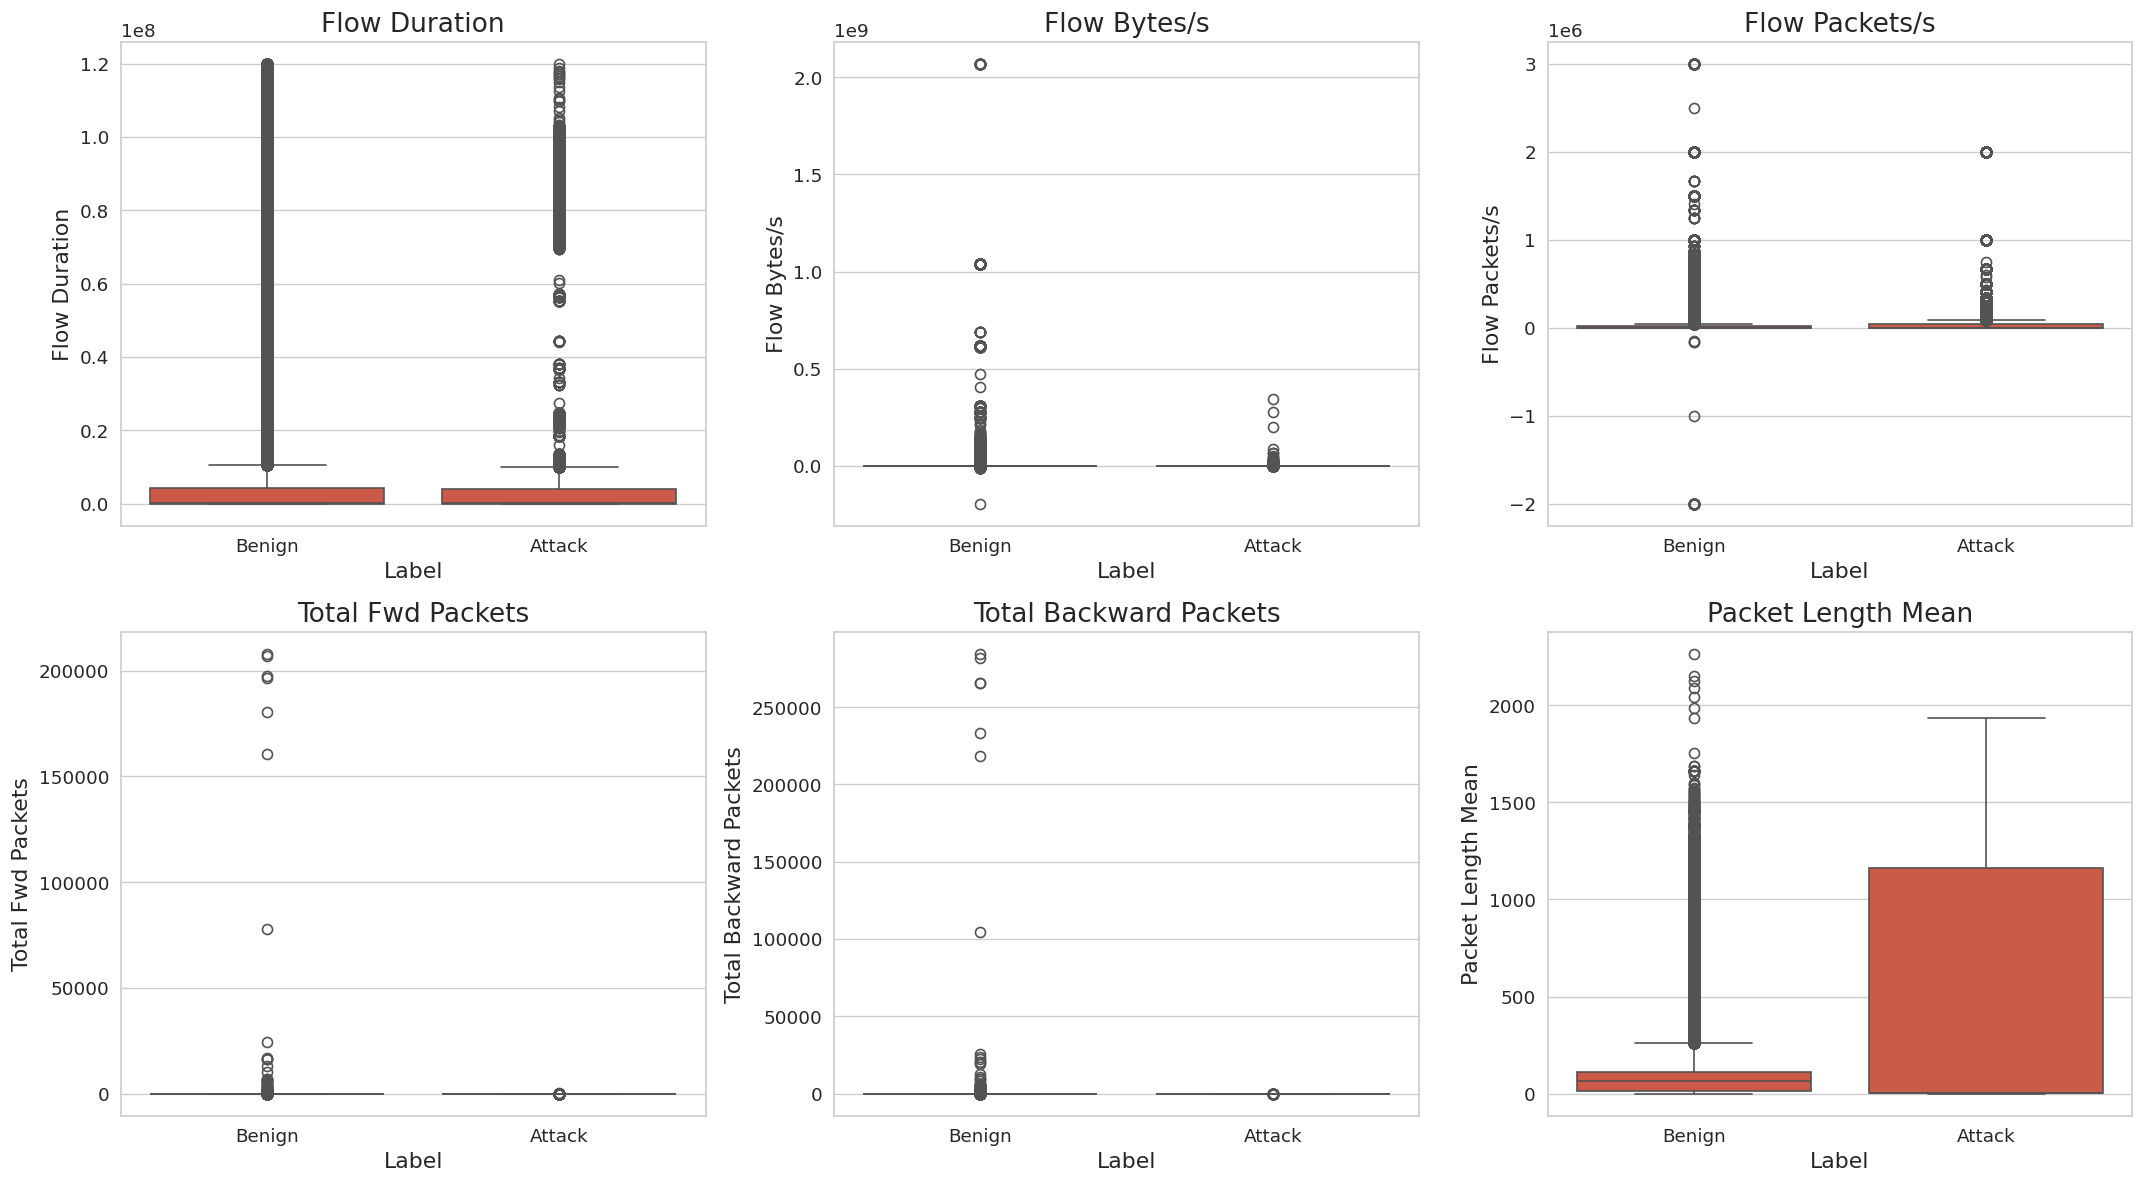

In [32]:
#Attack vs Benign....
fig, axes = plt.subplots(2,3,figsize=(18,10))

axes = axes.flatten()

for ax,col in zip(axes,features):

    sns.boxplot(
        data=df,
        x="Label",
        y=col,
        ax=ax
    )

    ax.set_xticklabels(["Benign","Attack"])

    ax.set_title(col)

plt.tight_layout()

plt.show()

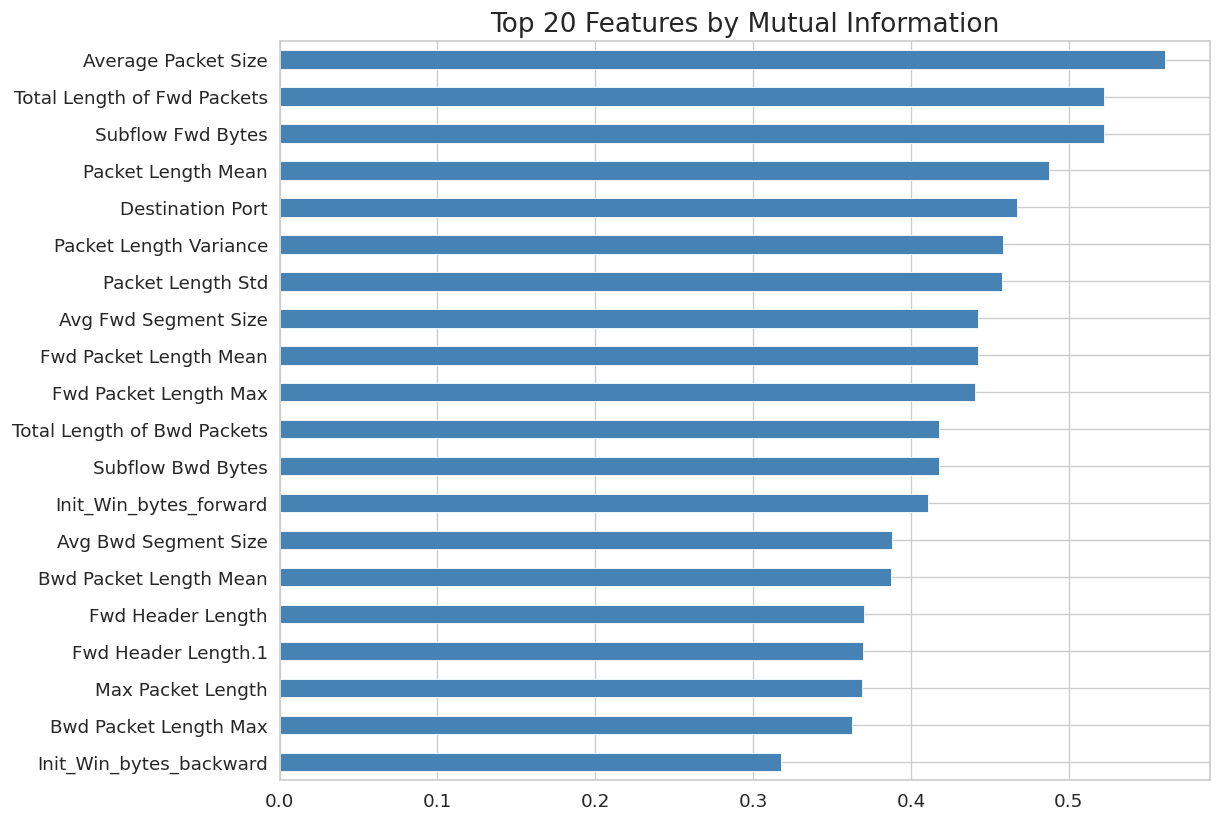

In [33]:
##Mutual information..
from sklearn.feature_selection import mutual_info_classif

X = df.drop(columns="Label")

y = df["Label"]

num_X = X.select_dtypes(include=np.number)

mi = mutual_info_classif(
    num_X,
    y,
    random_state=42
)

mi_scores = (
    pd.Series(
        mi,
        index=num_X.columns
    )
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,8))

mi_scores.head(20).sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top 20 Features by Mutual Information")

plt.show()

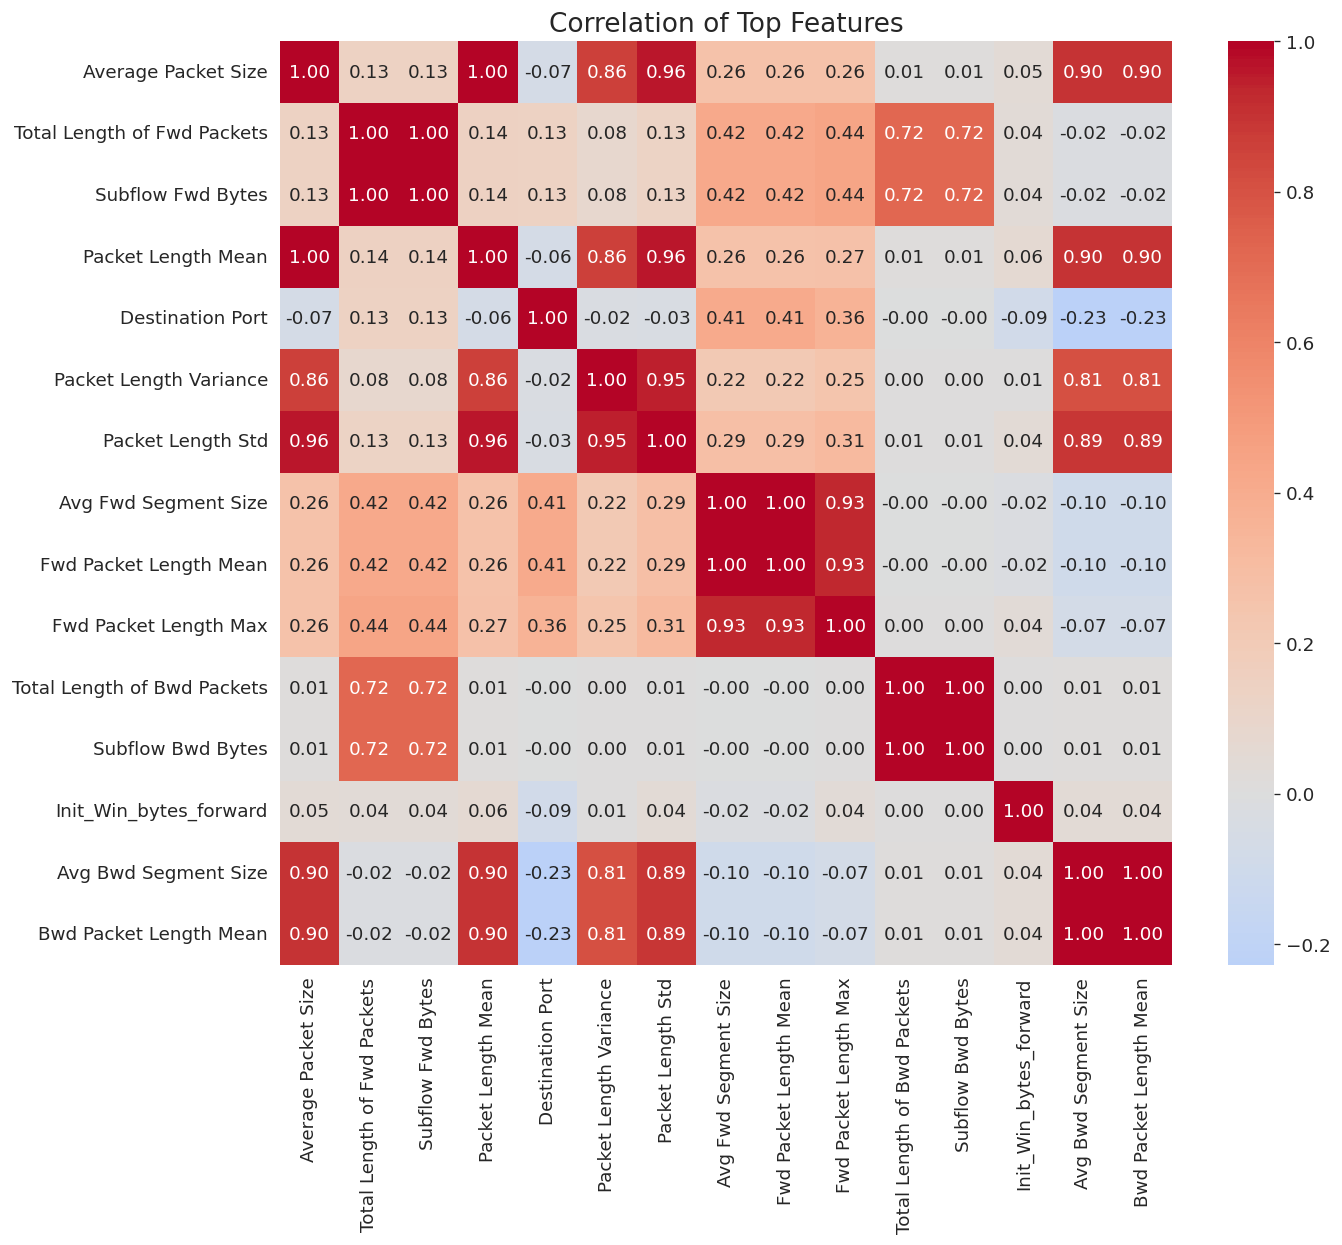

In [34]:
## Corelation among top features..
top_features = mi_scores.head(15).index

plt.figure(figsize=(12,10))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation of Top Features")

plt.show()

In [35]:
# df.drop(columns=["source_file"], inplace=True)


## Train test split....

In [36]:
X=df.drop(columns=["Label"])

y=df["Label"]

X_train,X_test,y_train,y_test=train_test_split(

X,

y,

test_size=0.2,

stratify=y,

random_state=42

)

# Leak free preprocessing pipeline...


In [37]:
#lead free preprocessing pipeline..
num_colsX = X_train.select_dtypes(include="number").columns

cat_colsX = X_train.select_dtypes(exclude="number").columns


numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_colsX),
    ("cat", categorical_pipe, cat_colsX),
])
def build_pipeline(model, use_smote=False):

    if use_smote:
        return ImbPipeline([
            ("prep", preprocessor),
            ("smote", SMOTE(random_state=SEED)),
            ("model", model)
        ])

    return Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
print("Numeric:", num_colsX)
print("Categorical:", cat_colsX)
print(df.head().T)

Numeric: Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SY

# Defining models...

In [38]:
models = {

    "XGBoost":             xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                                             subsample=0.9, colsample_bytree=0.9,
                                             tree_method="hist", eval_metric="mlogloss",
                                             n_jobs=-1, random_state=SEED),
    "LightGBM":            lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                                              class_weight="balanced", n_jobs=-1,
                                              random_state=SEED, verbose=-1),
}
print(f"{len(models)} models defined")

2 models defined


## . 5-fold Stratified Cross-Validation (headline results)

Each model is evaluated with the full preprocessing pipeline re-fit per fold.
We report **mean ± std** across folds so you can see which gaps are real vs. noise.


## Cross validation with SMOT

In [39]:
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=SEED)
scoring = {
    "Accuracy":  "accuracy",
    "Precision": "precision_macro",
    "Recall":    "recall",
    "F1":        "f1",
    "AUC":       "roc_auc",
}

rows = []
for name, mdl in models.items():
    t0 = time.time()
    cvres = cross_validate(build_pipeline(mdl, use_smote=True), X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"Model": name}
    for label in scoring:
        m, s = cvres[f"test_{label}"].mean(), cvres[f"test_{label}"].std()
        row[label] = f"{m:.5f} ± {s:.4f}"
        row[f"_{label}"] = m          # numeric copy for sorting/plotting
    row["Time (s)"] = round(time.time() - t0, 2)
    rows.append(row)
    print(f"  done: {name}")

results_df = (pd.DataFrame(rows)
              .sort_values("_F1", ascending=False)
              .reset_index(drop=True))
display_cols = ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC", "Time (s)"]
print("\nTABLE I — 5-fold CV (mean ± std)")
display(results_df[display_cols])

  done: XGBoost
  done: LightGBM

TABLE I — 5-fold CV (mean ± std)


,Model,Accuracy,Precision,Recall,F1,AUC,Time (s)
0,XGBoost,0.99870 ± 0.0001,0.99851 ± 0.0001,0.99850 ± 0.0001,0.99818 ± 0.0001,0.99999 ± 0.0000,245.72
1,LightGBM,0.99867 ± 0.0001,0.99847 ± 0.0001,0.99850 ± 0.0002,0.99814 ± 0.0001,0.99998 ± 0.0000,296.71


## . Hyperparameter tuning on the best model

Light `GridSearchCV` over the top model from CV. On a dataset this small the gains
are modest — the grid is intentionally compact to avoid overfitting the CV.


In [40]:
best_name = results_df.iloc[0]["Model"]
print("Best model from CV:", best_name)

param_grids = {

    "XGBoost":             {"model__max_depth": [3, 4, 5,7,9,10], "model__learning_rate": [0.03, 0.05, 0.1]},
    "LightGBM":            {"model__max_depth": [3, 4, 5,7,9,10], "model__learning_rate": [0.03, 0.05, 0.1]},
}

grid = param_grids.get(best_name, {})
best_pipe = build_pipeline(models[best_name])

if grid:
    search = GridSearchCV(best_pipe, grid, cv=cv, scoring="f1_macro", n_jobs=-1)
    search.fit(X, y)
    best_pipe = search.best_estimator_
    print("Best params:", search.best_params_)
    print(f"Tuned CV macro-F1: {search.best_score_:.4f}")
else:
    print("No grid defined; using default best pipeline.")

Best model from CV: XGBoost
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 7}
Tuned CV macro-F1: 0.9990


# Confusion matrix..

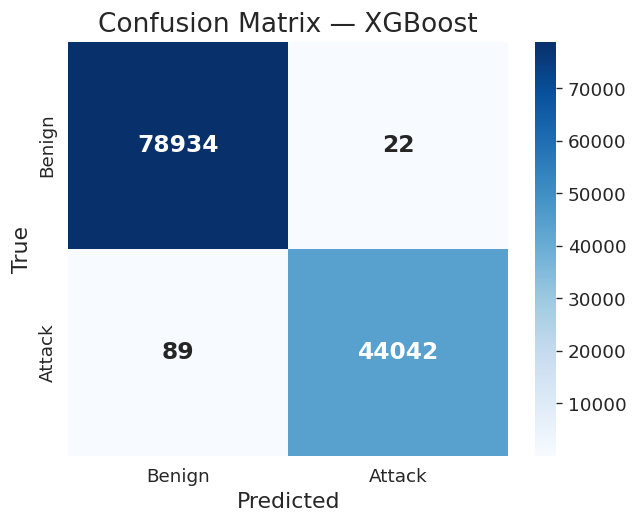

Classification report — XGBoost
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     78956
      Attack       1.00      1.00      1.00     44131

    accuracy                           1.00    123087
   macro avg       1.00      1.00      1.00    123087
weighted avg       1.00      1.00      1.00    123087



In [41]:

best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)
labels = ["Benign", "Attack"]
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={"size":14,"fontweight":"bold"}
)
ax.set(xlabel="Predicted", ylabel="True",
       title=f"Confusion Matrix — {best_name}")
plt.tight_layout(); plt.savefig("fig_confusion.png", bbox_inches="tight"); plt.show()

print(f"Classification report — {best_name}")


print(classification_report(
    y_test,
    y_pred,
    target_names=labels
))

# Feature importance..

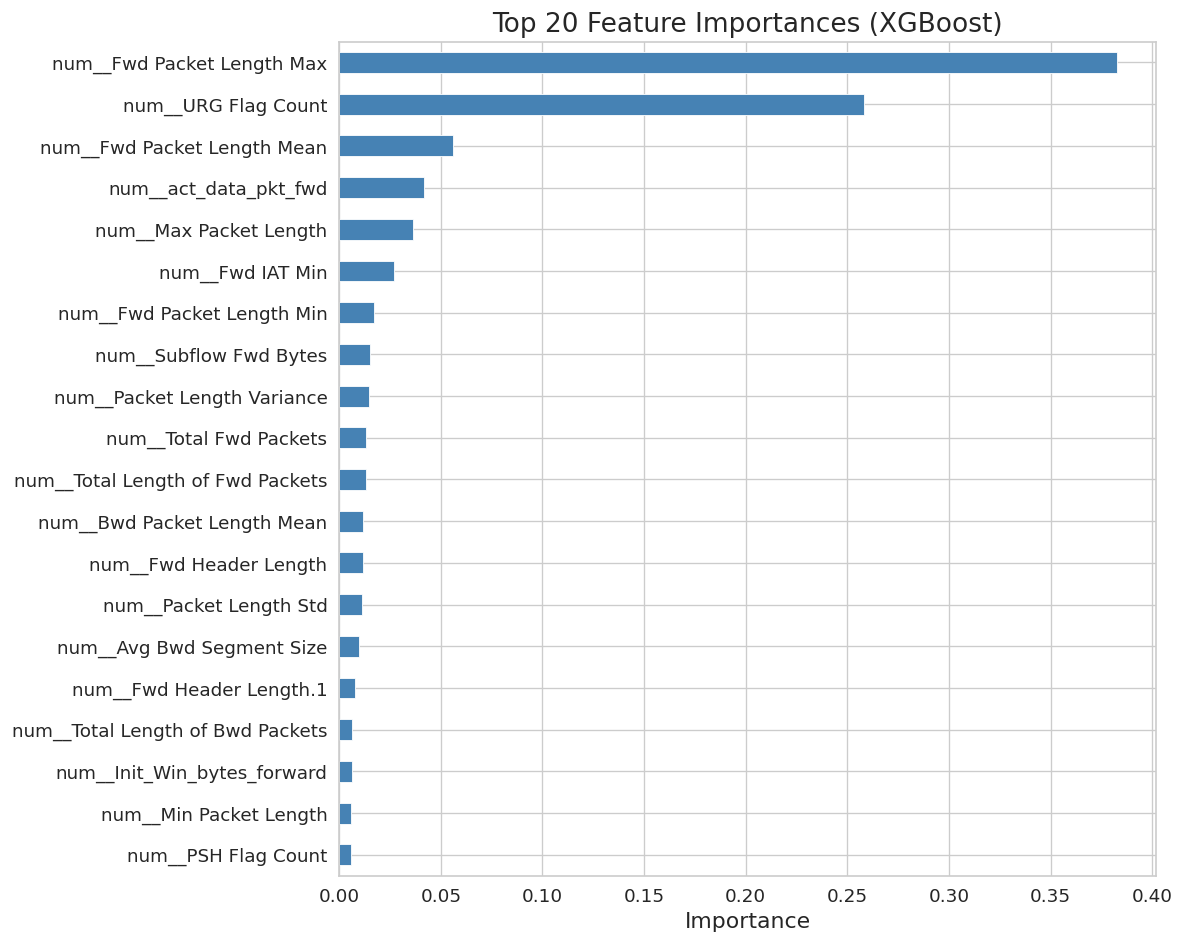

In [42]:

# Get feature names after preprocessing
feature_names = best_pipe.named_steps["prep"].get_feature_names_out()

# Get trained XGBoost model
model = best_pipe.named_steps["model"]

importance = pd.Series(
    model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10,8))

importance.head(20).sort_values().plot(
    kind="barh",
    color="steelblue"
)

plt.title("Top 20 Feature Importances (XGBoost)")
plt.xlabel("Importance")

plt.tight_layout()
plt.show()

# Model Perfomance comparision..

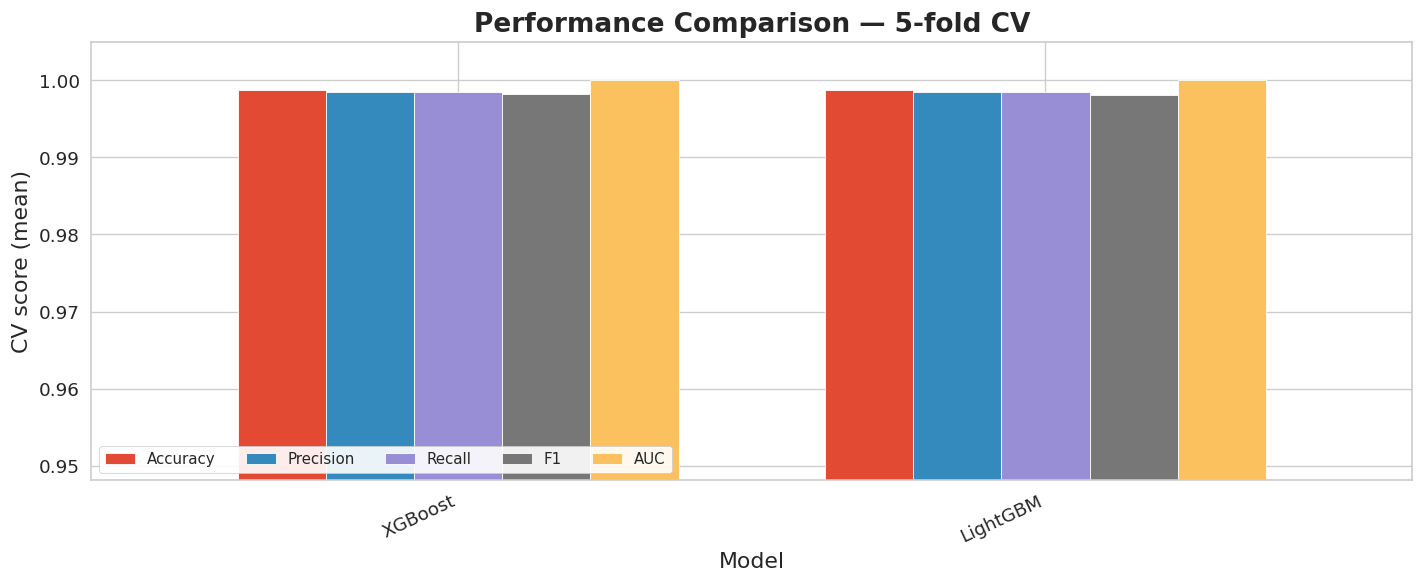

In [43]:
metric_cols = ["_Accuracy", "_Precision", "_Recall", "_F1", "_AUC"]
plot_df = results_df.set_index("Model")[metric_cols]
plot_df.columns = [c[1:] for c in metric_cols]

fig, ax = plt.subplots(figsize=(12, 5))
plot_df.plot(kind="bar", ax=ax, width=0.75, edgecolor="white", linewidth=0.5)
ax.set_ylim(max(0, plot_df.values.min() - 0.05), 1.005)
ax.set_ylabel("CV score (mean)")
ax.set_title("Performance Comparison — 5-fold CV", fontweight="bold")
ax.legend(loc="lower left", fontsize=9, ncol=5, framealpha=0.9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout(); plt.savefig("fig_comparison.png", bbox_inches="tight"); plt.show()

# Roc_Auc curve

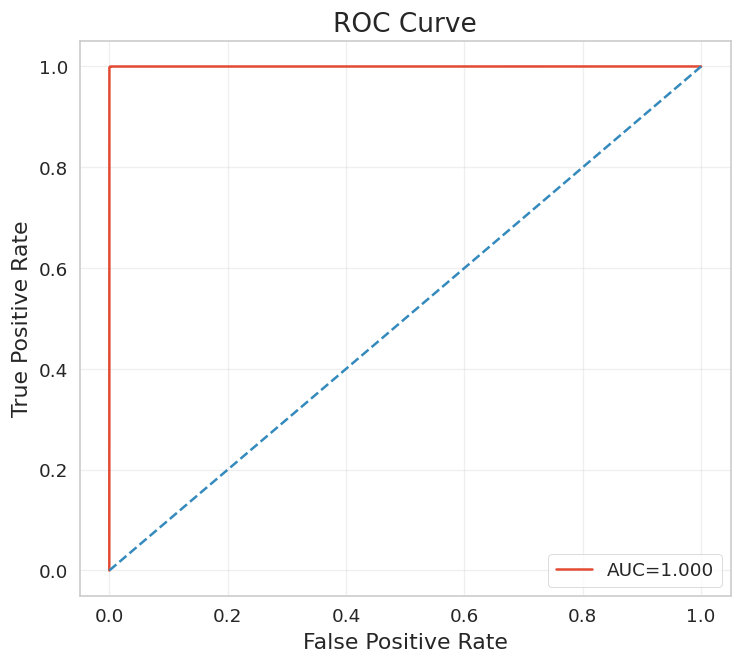

In [44]:
from sklearn.metrics import roc_curve, auc
best_pipe.fit(X_train,y_train)

prob = best_pipe.predict_proba(X_test)[:,1]

fpr,tpr,_=roc_curve(y_test,prob)

roc_auc=auc(fpr,tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr,tpr,
         label=f"AUC={roc_auc:.3f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.grid(alpha=.3)

plt.show()

# Explainable ai using SHAP..

In [45]:
import shap

model = best_pipe.named_steps["model"]

X_train_processed = best_pipe.named_steps["prep"].transform(X_train)

feature_names = best_pipe.named_steps["prep"].get_feature_names_out()

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_train_processed)

# SHAP summery plot ...

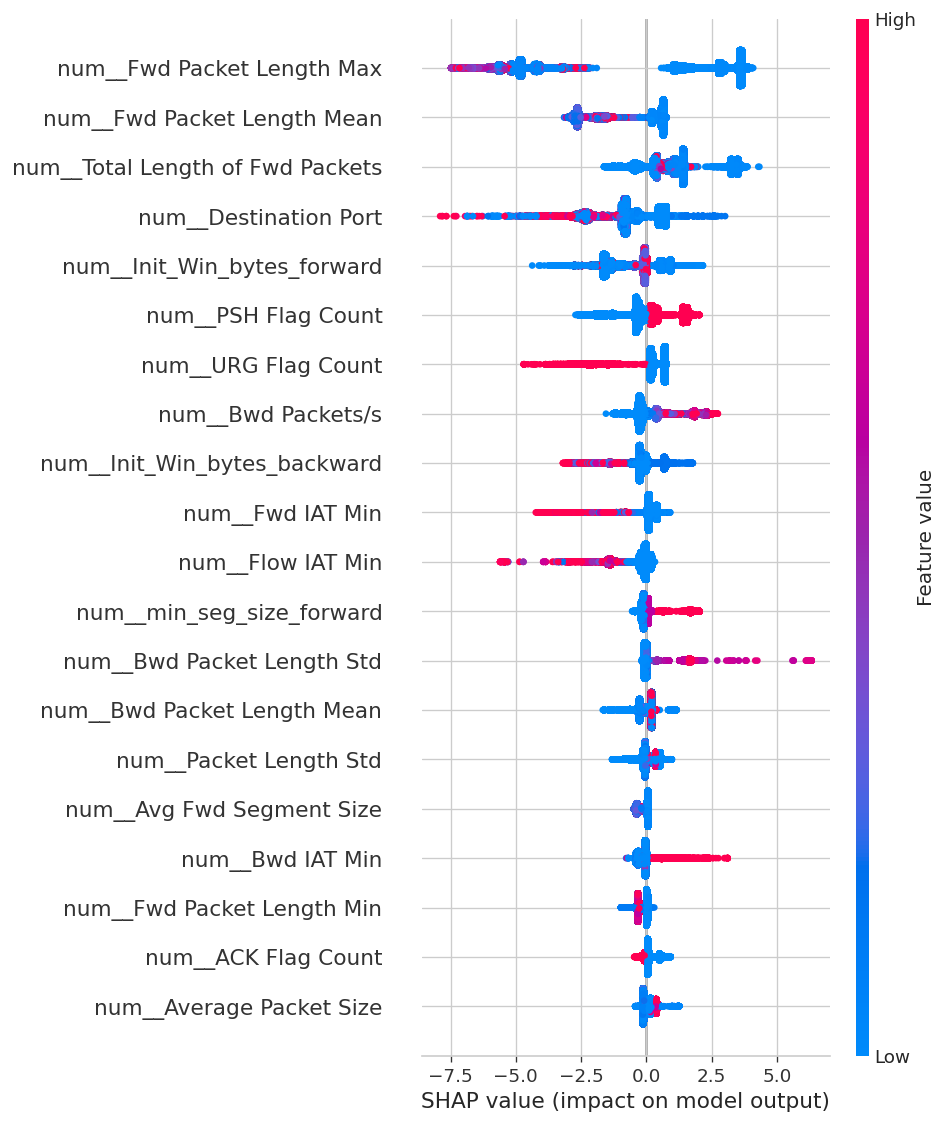

In [46]:
shap.summary_plot(
    shap_values,
    X_train_processed,
    feature_names=feature_names
)
plt.show()

# 📌 Conclusion

This project presented a complete end-to-end machine learning pipeline for network intrusion detection using the friday datasets of the **CIC-IDS2017 Working Hours** dataset. The objective was to distinguish benign network traffic from malicious activities through systematic data analysis, feature engineering, robust model evaluation, and explainable machine learning techniques.

Rather than focusing solely on achieving high predictive performance, this notebook emphasizes a **reproducible and research-oriented workflow**. The project follows modern machine learning best practices, including:

- Comprehensive data cleaning and preprocessing
- Exploratory Data Analysis (EDA) with publication-quality visualizations
- Mutual Information-based feature relevance analysis
- Leak-free preprocessing pipelines using Scikit-learn
- Stratified K-Fold Cross Validation for robust model assessment
- Hyperparameter optimization using GridSearchCV
- Comparative evaluation of multiple classical and ensemble learning algorithms
- ROC Curve analysis and confusion matrix evaluation
- Model-specific Feature Importance analysis
- SHAP (SHapley Additive exPlanations) for Explainable AI

Among the evaluated algorithms, ensemble tree-based methods demonstrated superior predictive capability, confirming their effectiveness in capturing complex patterns within network traffic data. The comparative analysis also highlighted the strengths and limitations of different classifiers, providing a balanced evaluation rather than relying on a single performance metric.

An additional investigation into **SMOTE-based class balancing** showed that synthetic oversampling did not provide a meaningful performance improvement for this dataset. Consequently, the final workflow favors the original data distribution, reducing computational complexity while maintaining strong predictive performance.

Although this study was conducted on a representative 30,000-record sample for efficient experimentation and development, the entire pipeline has been intentionally designed to scale seamlessly to the complete Friday subset of the CIC-IDS2017 dataset. This enables straightforward extension to significantly larger datasets without requiring structural modifications to the code.

## Key Contributions

- ✅ End-to-end intrusion detection pipeline
- ✅ Leak-free preprocessing architecture
- ✅ Comprehensive exploratory data analysis
- ✅ Feature relevance analysis using Mutual Information
- ✅ Comparative benchmarking of multiple machine learning algorithms
- ✅ Hyperparameter optimization
- ✅ Explainable AI through SHAP analysis
- ✅ Modular, reusable, and scalable implementation

## Future Work

Several opportunities remain for extending this work:

- Train and evaluate the pipeline on the complete CIC-IDS2017 dataset.
- Expand the study to additional CIC datasets (CIC-IDS2018, CIC-DDoS2019, CSE-CIC-IDS2018).
- Explore multiclass intrusion detection instead of binary classification.
- Investigate deep learning architectures such as CNNs, LSTMs, Autoencoders, and Transformer-based models.
- Incorporate advanced explainability methods and model calibration techniques.
- Deploy the final model as a real-time intrusion detection system using REST APIs or edge devices.

---

"This work establishes a reproducible and scalable machine learning framework for intrusion detection using the CIC-IDS2017 dataset. The developed pipeline provides a strong foundation for future cybersecurity research, large-scale experimentation, and deployment-oriented intrusion detection systems."

In [47]:
import joblib

joblib.dump(
    best_pipe,
    "CICIDS2017_FullFriday_XGBoost.joblib"
)

print("Model saved successfully.")

from google.colab import files

files.download("CICIDS2017_FullFriday_XGBoost.joblib")

Model saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
model_package = {
    "model": best_pipe,
    "feature_names": list(X.columns),
    "target": "Label",
    "dataset": "CICIDS2017 - Friday",
    "algorithm": "XGBoost",
    "version": "1.0"
}

joblib.dump(
    model_package,
    "CICIDS2017_IDS_Model.joblib"
)

print("Model package saved.")

Model package saved.
